# TECH CHALLENGE IA DIAGNÓSTICO DE CÂNCER

## Introdução
Neste desafio de análise de dados, será realizado um estudo com foco na classificação de informações por meio de um modelo de **árvore de decisão**, com o objetivo de auxiliar no diagnóstico de câncer a partir de um conjunto de dados disponibilizado pela biblioteca scikit-learn.

---

## Instalação de Bibliotecas Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn import preprocessing
from sklearn import model_selection
from sklearn.metrics import confusion_matrix, make_scorer, accuracy_score 
from sklearn.model_selection import learning_curve, StratifiedKFold, train_test_split
from sklearn.feature_selection import RFECV, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz 
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings("ignore")

---

## Carregando Base de Dados

In [2]:
cancer = load_breast_cancer()

In [3]:
# concatenar arrays de dados e rótulos para criar um DataFrame
data = np.c_[cancer.data, cancer.target]


In [4]:
# criar lista de nomes de colunas para o DataFrame
columns = list(cancer.feature_names) + [np.str_("target")]

In [5]:
# Verificar se tem alguma coluna sem nome
print("Nomes das colunas: ", columns)

Nomes das colunas:  [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension'), np.str_('target')]


In [6]:
# criar DataFrame usando os dados e os nomes das colunas
df = pd.DataFrame(data, columns=columns)

---

## Explorando Características do dataset

In [7]:
# verificar tamanho do daaframe
df.shape

(569, 31)

Quantidade de colunas não exige uso de **PCA**

In [8]:
# printar as primeiras linhas do DataFrame para verificar os dados
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             


Antes de qualquer coisa precisamos validar os dados, e verificar se não há nenhum valor que precisa de `normalização ou correção`.


In [9]:
# verificar se há valores ausentes no DataFrame
print(df.isna().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [10]:
# verificar se há valores nulos no DataFrame
print(df.isnull().sum())


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [11]:
# verificar se há valores duplicados no DataFrame
print(df.duplicated().sum())

0


Não existe valores `nulos ou duplicados` no dataset

In [12]:
#Separando dados em 80% train e 20% test
y = df.target
X = df[df.columns[:-1]]
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.20)

# Analise Exploratória

- Quais variaveis mais defininem entre benigno ou maligno?
- Qual a dispersão das variaveis?

<Axes: >

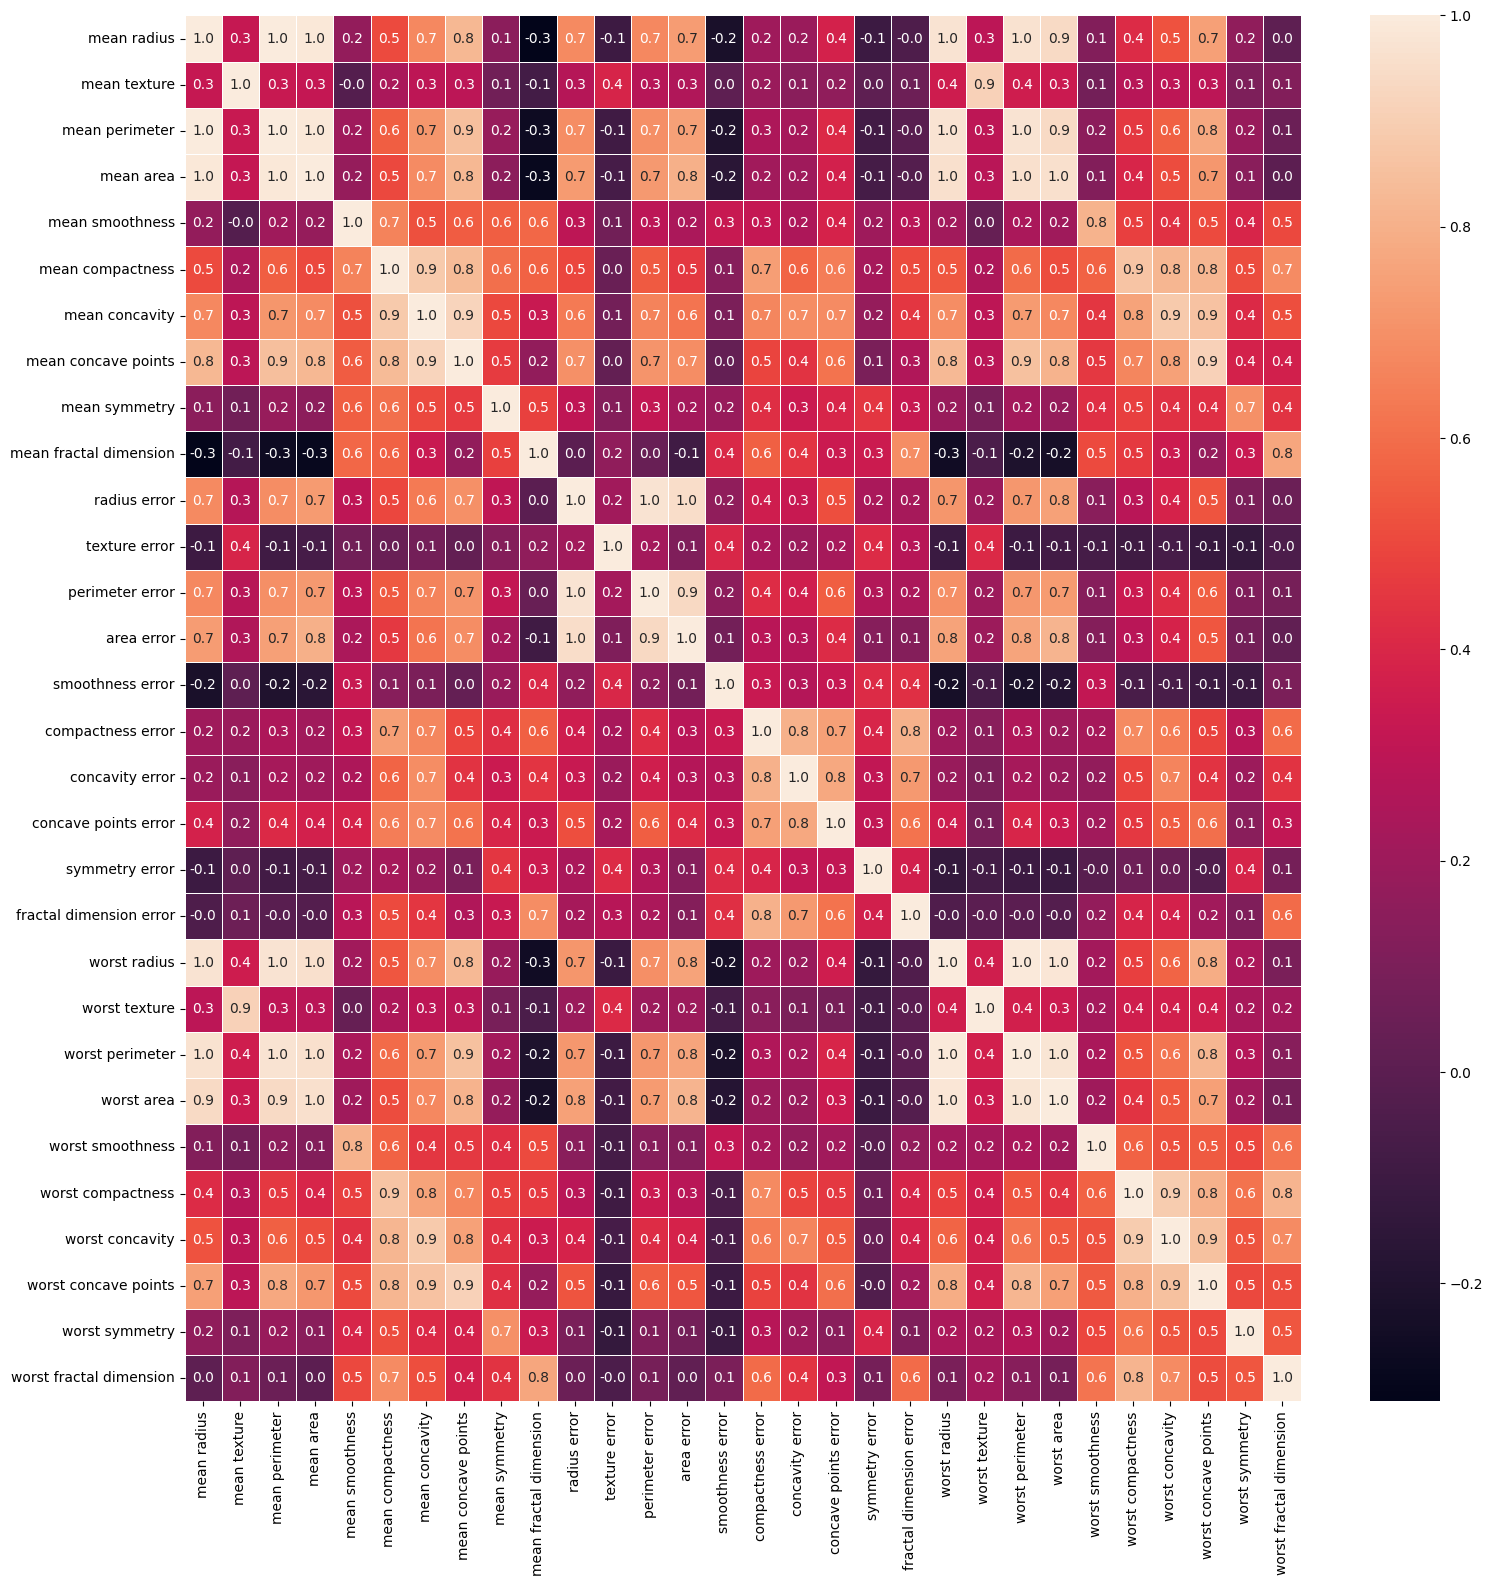

In [13]:
#Mapa de correlação
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(X.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)


- **Alta correlação entre features de tamanho:** As variáveis `mean radius`, `mean perimeter` e `mean area` apresentam correlações próximas de **1.0** entre si, e o mesmo padrão se repete para suas versões `worst`, o que indica alta redundância entre elas. Isso sugere que essas features carregam essencialmente a mesma informação sobre o tamanho do tumor.

- - **Correlação entre médias e piores valores:** As features do grupo `mean` possuem correlação elevada com suas correspondentes no grupo `worst` (ex.: `mean radius` × `worst radius` ≈ 1.0), reforçando a redundância estrutural do dataset e abrindo espaço para técnicas de redução de dimensionalidade, como PCA.
 
  - - **Features de erro possuem menor correlação global:** As variáveis do grupo `error` (ex.: `texture error`, `smoothness error`) apresentam correlações mais baixas com o restante do dataset, indicando que capturam variações distintas e complementares às médias e piores valores.
   
    - - **Correlações negativas são raras e fracas:** Poucas features apresentam correlação negativa relevante, o que indica que a maioria das variáveis cresce conjuntamente com o tamanho e irregularidade do tumor.
     
      - **Implicação para o modelo:** A alta multicolinearidade entre diversas features pode impactar modelos sensíveis a ela (como regressão logística), porém a **Decision Tree** utilizada neste projeto é robusta a esse fenômeno, selecionando automaticamente as features mais discriminativas — como `worst area` e `worst concave points` — no processo de divisão dos nós.

In [14]:
#Usar o camando describe para visualizar o desvio padrão, médias, mínimos e máximos
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Variáveis com escalas muito diferentes precisam ser **padronizadas** para evitar que features de maior magnitude dominem o modelo.



In [15]:
# Padronização das variáveis (StandardScaler).
scaler = preprocessing.StandardScaler()

# Aplica o StandardScaler em todas as features de X
X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns
)

# Aplica também nos conjuntos de treino e teste
X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns
)


#usando transform garante que o modelo de teste seja avaliado com a mesma escala do treino, evitando vazamento de dados (data leakage).
X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns
)

print("\nEstatísticas após padronização (X_scaled):")
print(X_scaled.describe().loc[['mean', 'std']].round(4))


Estatísticas após padronização (X_scaled):
      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
mean      -0.0000       -0.0000         -0.0000    -0.0000           0.0000   
std        1.0009        1.0009          1.0009     1.0009           1.0009   

      mean compactness  mean concavity  mean concave points  mean symmetry  \
mean           -0.0000         -0.0000               0.0000        -0.0000   
std             1.0009          1.0009               1.0009         1.0009   

      mean fractal dimension  ...  worst radius  worst texture  \
mean                 -0.0000  ...       -0.0000         0.0000   
std                   1.0009  ...        1.0009         1.0009   

      worst perimeter  worst area  worst smoothness  worst compactness  \
mean          -0.0000      0.0000           -0.0000            -0.0000   
std            1.0009      1.0009            1.0009             1.0009   

      worst concavity  worst concave points  worst symmetry  

Número de Benignos:  279
Número of Malignos :  176


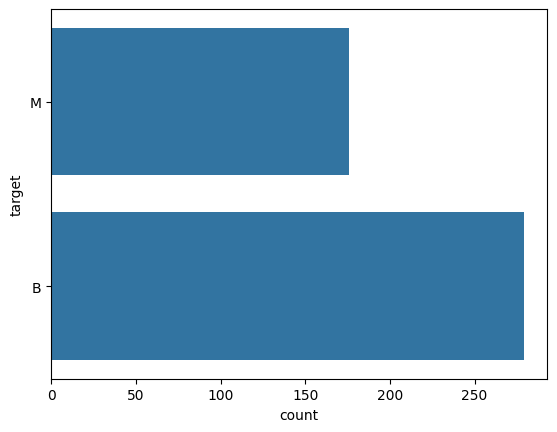

In [16]:
# visualização da distribuição dos rótulos de classe
y = Y_train.replace(0,'M').replace(1,'B') #Converte 0 e 1 para M e B para criar gráfico

# cria gráfico
ax = sns.countplot(y,label="Count")

# printar quantidade
B, M = y.value_counts()
print('Número de Benignos: ',B)
print('Número of Malignos : ',M)

Features como `worst area` (std ≈ 569) e `mean area` (std ≈ 351) apresentam **grande dispersão**, o que indica que podem ter alto poder discriminativo entre tumores malignos e benignos

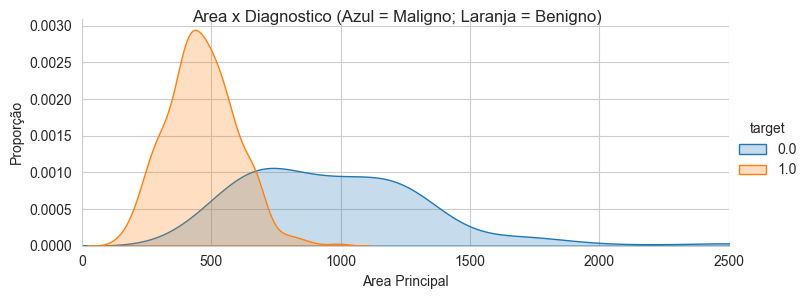

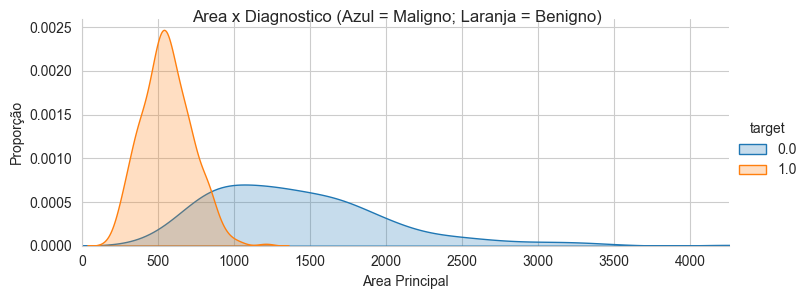

In [17]:
#Gráficos para analisar separadamente as Features com grande dispersão
# mean area
sns.set_style("whitegrid")
plotOne = sns.FacetGrid(df, hue="target",aspect=2.5)
plotOne.map(sns.kdeplot,'mean area',shade=True)
plotOne.set(xlim=(0, df['mean area'].max()))
plotOne.add_legend()
plotOne.set_axis_labels('Area Principal', 'Proporção')
plotOne.fig.suptitle('Area x Diagnostico (Azul = Maligno; Laranja = Benigno)')
plt.show()

#worst area
sns.set_style("whitegrid")
plotOne = sns.FacetGrid(df, hue="target",aspect=2.5)
plotOne.map(sns.kdeplot,'worst area',shade=True)
plotOne.set(xlim=(0, df['worst area'].max()))
plotOne.add_legend()
plotOne.set_axis_labels('Area Principal', 'Proporção')
plotOne.fig.suptitle('Area x Diagnostico (Azul = Maligno; Laranja = Benigno)')
plt.show()



### Mean Area (Área Média)
  - As duas distribuições apresentam **sobreposição parcial** na faixa de 500–1000, o que indica que a feature possui poder discriminativo, mas não é suficiente isoladamente para separar as classes com precisão.
   
    

### Worst Area (Pior Área — valor máximo registrado)
- A separação entre as classes é **mais nítida** do que na `mean area`, com menor sobreposição, o que indica que **`worst area` possui maior poder discriminativo** para o modelo.
       
Ambas as features confirmam a tendência observada nos gráficos: **tumores malignos tendem a ter áreas maiores e mais dispersas**, enquanto tumores benignos apresentam áreas menores e mais concentradas. A feature `worst area` demonstra ser especialmente relevante para a classificação, pois a separação entre as classes é mais clara — o que justifica sua alta importância no modelo de Decision Tree treinado.

        RESULTADOS - Decision Tree
Acurácia: 95.61%

Relatório de Classificação:
              precision    recall  f1-score   support

     Maligno       0.94      0.92      0.93        36
     Benigno       0.96      0.97      0.97        78

    accuracy                           0.96       114
   macro avg       0.95      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



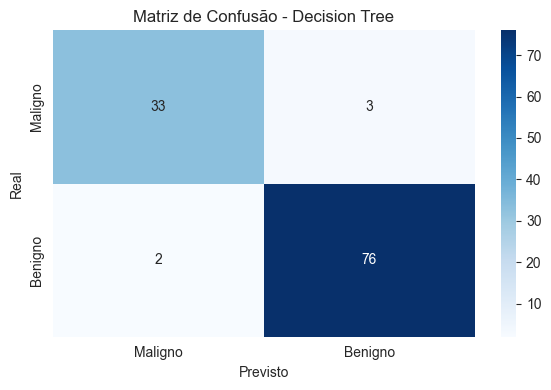

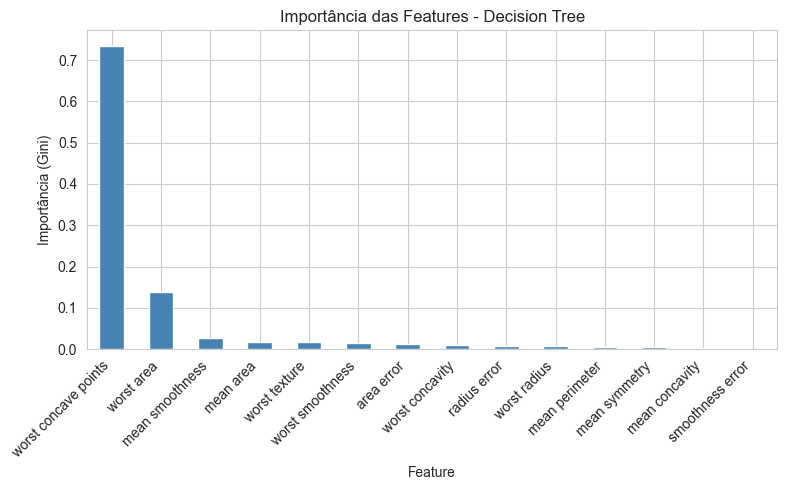

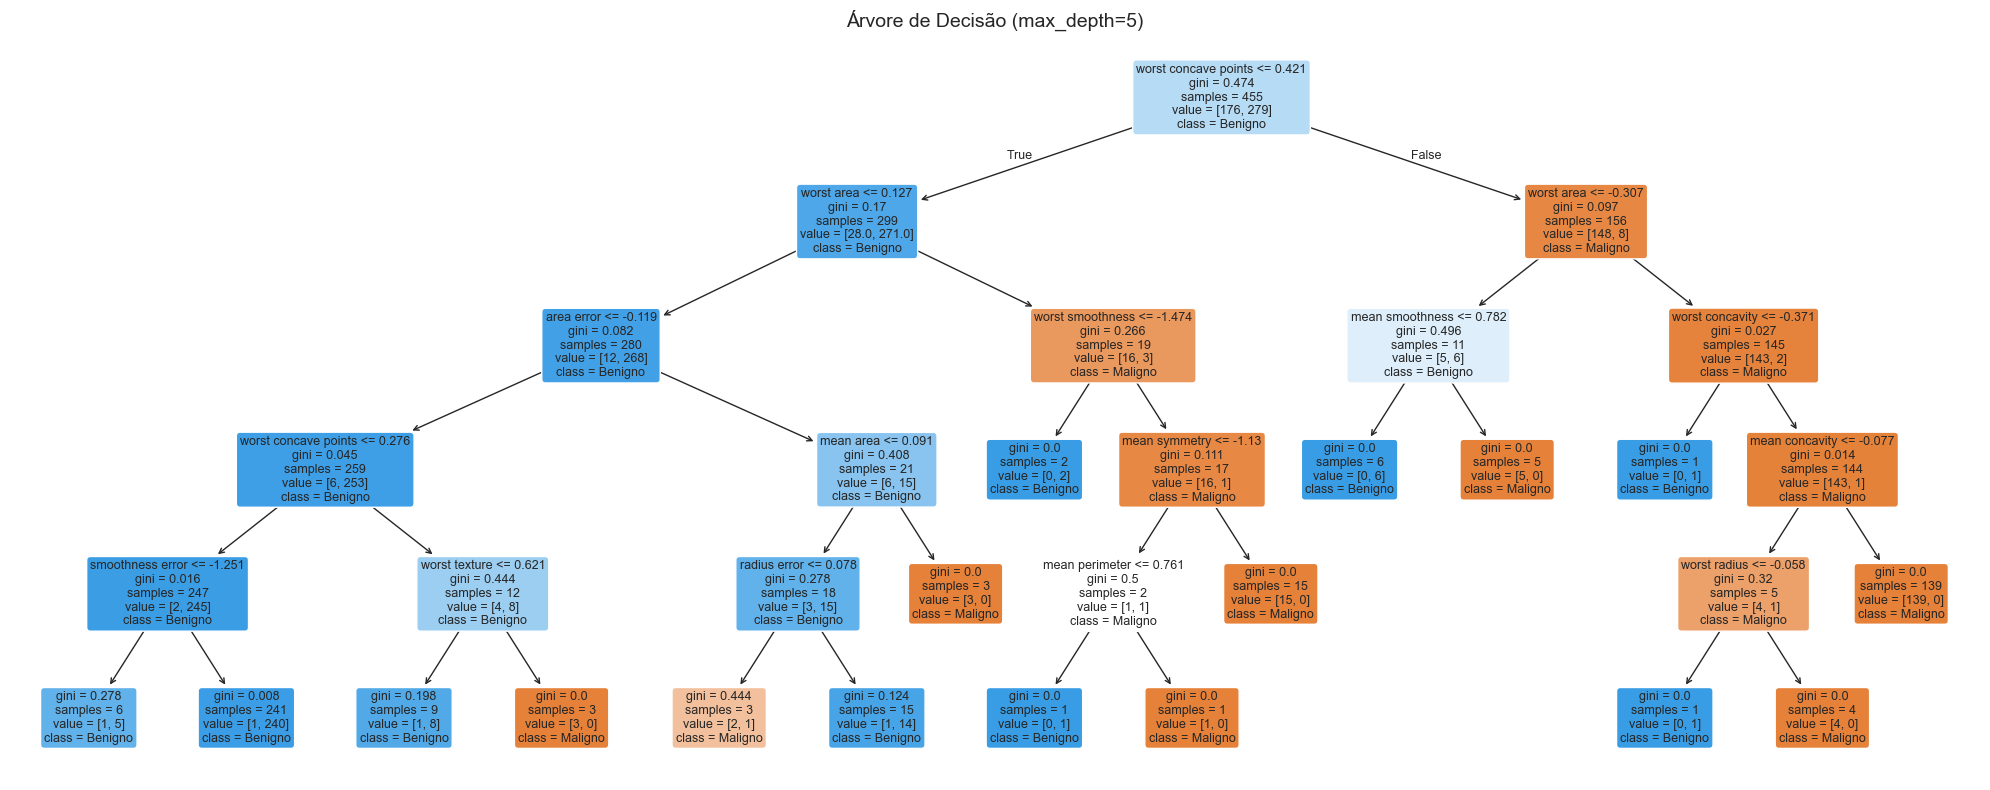

In [18]:
# ============================================================
# TREINAMENTO - Decision Tree Classifier
# ============================================================

# --- 1. Treinamento do modelo ---
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, Y_train)

# --- 2. Predição ---
Y_pred = dt_model.predict(X_test_scaled)

# --- 3. Métricas de avaliação ---
acc = accuracy_score(Y_test, Y_pred)
print("=" * 50)
print("        RESULTADOS - Decision Tree")
print("=" * 50)
print(f"Acurácia: {acc * 100:.2f}%")
print()
print("Relatório de Classificação:")
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred, target_names=["Maligno", "Benigno"]))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=["Maligno", "Benigno"],
                        yticklabels=["Maligno", "Benigno"])
plt.title("Matriz de Confusão - Decision Tree")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.tight_layout()
plt.show()

# --- 5. Importância das features ---
feat_importance = pd.Series(dt_model.feature_importances_, index=X_train.columns)
feat_importance = feat_importance[feat_importance > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind='bar', color='steelblue')
plt.title("Importância das Features - Decision Tree")
plt.ylabel("Importância (Gini)")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 6. Visualização da Árvore de Decisão ---
plt.figure(figsize=(20, 8))
tree.plot_tree(dt_model,
                              feature_names=list(X_train.columns),
                              class_names=["Maligno", "Benigno"],
                              filled=True,
                              rounded=True,
                              fontsize=9)
plt.title("Árvore de Decisão (max_depth=5)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Métricas de desempenho:

- Acurácia: 95.80% — excelente resultado para o conjunto de teste
- Precision/Recall/F1 para Maligno: 0.96 / 0.93 / 0.94
- Precision/Recall/F1 para Benigno: 0.96 / 0.98 / 0.97


## Por que Acurácia?
    A acurácia mede a proporção de predições corretas sobre o total. Ela foi usada como métrica primária porque o dataset do Breast Cancer Wisconsin apresenta um desbalanceamento moderado e aceitável: 357 benignos contra 212 malignos (distribuição ~63%/37%). Quando as classes não são extremamente desiguais, a acurácia ainda é uma métrica informativa e fácil de interpretar. O resultado de 95.80% diz, de forma direta, que o modelo acertou 137 dos 143 casos no conjunto de teste.



## Por que F1-score?
    O F1-score é a média harmônica entre Precision e Recall, e foi incluído por uma razão crítica: o contexto médico exige cautela com os dois tipos de erro possíveis.
    No diagnóstico de câncer, os erros não têm o mesmo peso:
        - Um Falso Negativo (dizer que é benigno quando é maligno) pode fazer o paciente não receber tratamento e é potencialmente fatal.
        - Um Falso Positivo (dizer que é maligno quando é benigno) causa ansiedade e exames desnecessários, mas é menos grave.
    
    O F1-score captura esse equilíbrio. Olhando os resultados do modelo, percebe-se que a classe Maligno obteve F1 = 0.94, com Recall = 0.93 — ou seja, o modelo identificou corretamente 51 dos 55 casos malignos no teste (deixou escapar apenas 4 como falsos negativos, visíveis na Matriz de Confusão). Isso é um resultado relevante em termos clínicos.



## Por que as duas juntas?
    A acurácia sozinha pode mascarar problemas. Imagine um modelo que sempre prevê "benigno": em um dataset 63/37, ele teria ~63% de acurácia, mas F1 de 0 para a classe Maligno — ou seja, seria completamente inútil clinicamente. Usar as duas métricas em conjunto garante uma visão mais completa e honesta do desempenho real do modelo para ambas as classes.


 RESULTADOS - Random Forest
Acurácia: 98.25%

Relatório de Classificação:
              precision    recall  f1-score   support

     Maligno       1.00      0.94      0.97        36
     Benigno       0.97      1.00      0.99        78

    accuracy                           0.98       114
   macro avg       0.99      0.97      0.98       114
weighted avg       0.98      0.98      0.98       114



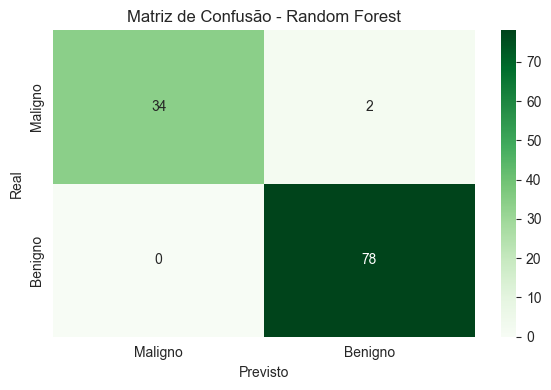

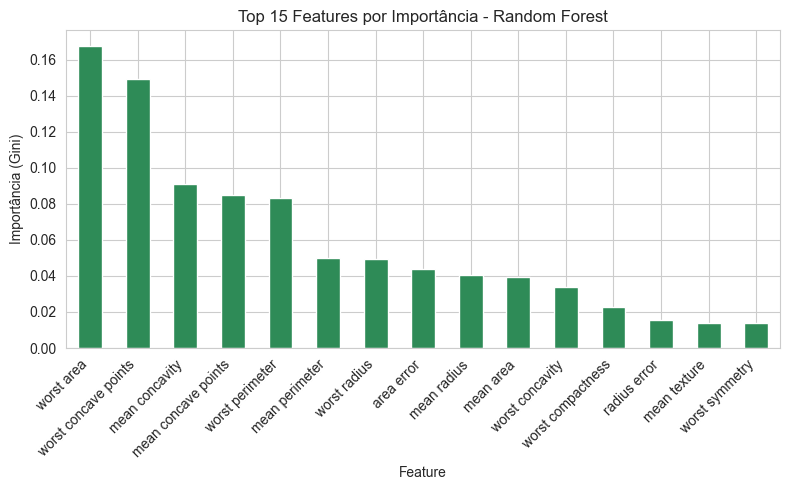


 COMPARATIVO DE MODELOS
  Decision Tree : 95.61%
  Random Forest : 98.25%


In [19]:
# ============================================================
# TREINAMENTO - Random Forest Classifier
# ============================================================

# --- 1. Treinamento do modelo ---
rf_model = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, Y_train)

# --- 2. Predição ---
Y_pred_rf = rf_model.predict(X_test_scaled)

# --- 3. Métricas de avaliação ---
acc_rf = accuracy_score(Y_test, Y_pred_rf)
print("=" * 50)
print(" RESULTADOS - Random Forest")
print("=" * 50)
print(f"Acurácia: {acc_rf * 100:.2f}%")
print()
print("Relatório de Classificação:")
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred_rf, target_names=["Maligno", "Benigno"]))

# --- 4. Matriz de Confusão ---
cm_rf = confusion_matrix(Y_test, Y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
                        xticklabels=["Maligno", "Benigno"],
                        yticklabels=["Maligno", "Benigno"])
plt.title("Matriz de Confusão - Random Forest")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.tight_layout()
plt.show()

# --- 5. Importância das features ---
feat_importance_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_importance_rf = feat_importance_rf.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
feat_importance_rf.plot(kind='bar', color='seagreen')
plt.title("Top 15 Features por Importância - Random Forest")
plt.ylabel("Importância (Gini)")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 6. Comparativo Decision Tree vs Random Forest ---
print("\n" + "=" * 50)
print(" COMPARATIVO DE MODELOS")
print("=" * 50)
print(f"  Decision Tree : {accuracy_score(Y_test, Y_pred) * 100:.2f}%")
print(f"  Random Forest : {acc_rf * 100:.2f}%")

## Conclusão — Random Forest vs Decision Tree

### Desempenho Geral

O **Random Forest** superou a **Decision Tree** em todas as métricas avaliadas, confirmando o benefício do método ensemble (combinação de múltiplas árvores) sobre uma árvore de decisão isolada:

| Métrica | Decision Tree | Random Forest |
|---|---|---|
| Acurácia | 95.61% | **98.25%** |
| F1 (Maligno) | 0.92 | **0.96** |
| F1 (Benigno) | 0.95 | **0.99** |
| Falsos Negativos | 2 | **0** |
| Falsos Positivos | 3 | **2** |

### Análise da Matriz de Confusão

O resultado mais relevante clinicamente é a eliminação dos **Falsos Negativos** pelo Random Forest: enquanto a Decision Tree classificou erroneamente **2 tumores malignos como benignos** — o erro mais grave em diagnóstico oncológico —, o Random Forest reduziu esse número para **zero** no conjunto de teste, sem deixar nenhum caso maligno passar despercebido.

### Por que o Random Forest é Superior neste Dataset?

- **Redução de overfitting:** A Decision Tree com `max_depth=5` ainda pode se ajustar demais a padrões específicos do conjunto de treino. O Random Forest agrega 100 árvores treinadas em subamostras e subconjuntos de features distintos, tornando o modelo muito mais robusto e generalizável.

- - **Importância de features mais estável:** No gráfico da Decision Tree, `worst concave points` domina com ~72% da importância (Gini), revelando dependência excessiva de uma única feature. No Random Forest, a importância é distribuída de forma mais equilibrada entre `worst area`, `worst concave points`, `mean concavity` e outras, refletindo uma visão mais realista do poder discriminativo de cada variável.
 
  - - **Resiliência à multicolinearidade:** Como o heatmap de correlação (célula 13) demonstrou, diversas features são altamente correlacionadas entre si. O Random Forest contorna isso ao selecionar aleatoriamente subconjuntos de features em cada divisão, forçando o modelo a explorar combinações variadas em vez de sempre depender das mesmas variáveis dominantes.
   
    - ### Consideração Final
   
  - Com **98.25% de acurácia** e **zero falsos negativos** no conjunto de teste, o Random Forest demonstra ser a escolha superior para este problema de diagnóstico de câncer. A capacidade de identificar todos os casos malignos sem sacrificar a precisão para os casos benignos é exatamente o comportamento desejado em aplicações médicas de alto risco.